# Tutorial 1: Quickstart Scientific Taste

Estimated time: 20-30 minutes

## Prerequisites
No optional dependencies required.

## Learning aims
- Primary package aim: run `validate -> plan -> run -> runs list/show` on a typed spec
- Secondary scientific aim: relate input perturbations (`a`, `b`) to output behavior (`sum`, `product`)

## Success criteria
- you can explain one observed trend in `sum` and one in `product` from the heatmaps


## Why this tutorial matters

This is the smallest possible loop through the whole framework: one spec, one DOE, one centralized sweep table, two output channels. Doing it once on a closed-form toy model means **you'll recognize the shape when you hit it on a real biological model in T2**, where the inputs become reaction rates and the outputs become time-series. By the end you'll be able to drive `validate → plan → run` on any spec without reading the docs again.


## Step 1: Validate and plan


In [1]:
# Cross-platform setup (Windows / macOS / Linux) — no shell, no PYTHONPATH prefix.
# Find the repo root so `src/` is importable, then load the shared tutorial helpers.
import sys
from pathlib import Path

_root = Path.cwd().resolve()
while not (_root / "src" / "bayesian_metamodeling").is_dir() and _root != _root.parent:
    _root = _root.parent
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

from bayesian_metamodeling.tutorial import bootstrap, run_mm_cli, run_tool

root = bootstrap()  # chdir to repo root + ensure src/ on sys.path (idempotent)
ROOT = root
print("Repo root:", root)


Repo root: /Users/barakraveh/Git/metamodeler_codex_scaffold_docs


**`validate` and `plan` are two distinct steps**, intentionally separated:

- **`validate`** checks the spec is well-formed — types, required fields, contract consistency between `io_schema` / `design` / `adapter`. Catches structural bugs before any model runs.
- **`plan`** is read-only too: it enumerates the actual DOE points the spec will produce, without executing the model. Use this to budget the work before launching it (the toy model below has 9 points; a real biological sweep can have 1000s).

Doing them in this order means: first you trust the spec is sane, then you see what it'll do, then you launch the run.


In [2]:
SPEC_PATH = "tutorials/specs/model.toy.grid.json"

run_mm_cli("validate", SPEC_PATH)
run_mm_cli("plan", SPEC_PATH)


$ bayesmm validate tutorials/specs/model.toy.grid.json
Spec validation passed: model=toy_program_tutorial, strategy=grid, adapter=python_cli_adapter_v1
$ bayesmm plan tutorials/specs/model.toy.grid.json
Plan points: 9
Preview:
1: {'a': 0.0, 'b': 0.0}
2: {'a': 0.0, 'b': 1.0}
3: {'a': 0.0, 'b': 2.0}
4: {'a': 1.0, 'b': 0.0}
5: {'a': 1.0, 'b': 1.0}


0

## Step 2: Execute sweep and list run IDs


In [3]:
run_mm_cli("run", SPEC_PATH)
run_mm_cli("runs", "list")


$ bayesmm run tutorials/specs/model.toy.grid.json
Running point 1/9: {'a': 0.0, 'b': 0.0}
Running point 2/9: {'a': 0.0, 'b': 1.0}
Running point 3/9: {'a': 0.0, 'b': 2.0}
Running point 4/9: {'a': 1.0, 'b': 0.0}
Running point 5/9: {'a': 1.0, 'b': 1.0}
Running point 6/9: {'a': 1.0, 'b': 2.0}
Running point 7/9: {'a': 2.0, 'b': 0.0}
Running point 8/9: {'a': 2.0, 'b': 1.0}
Running point 9/9: {'a': 2.0, 'b': 2.0}
Stored sweep run: 31a61634d83c4d73abe37a2ff538c403
Run complete: 9 successful runs
$ bayesmm runs list
Registered runs: 70
- 009bdc6041b24c6e986e0d3284cda3fd
- 06d27f97bcc041da8d11efd106b6620a
- 0911649eedb746fa96a5781ffe5be292
- 0f624140a9f24cf7a68513dda1899654
- 106064b46b8546beb0327f96a3bc5966
- 135ec2b7d7814c0ab69b7aabeb47721e
- 1f49c57583c946b5be7ea4b613677b74
- 22d72cbfd82d4f2088ca73b686cee2cb
- 24009e48a21d49239ce5fab672953e80
- 27f7b5c27f3b47cf86bbf7a1b91dbd86
- 28b7c9f01eb54ae1b5dc83f035abc75d
- 31a61634d83c4d73abe37a2ff538c403
- 3be0370560284d9bb9cfe0775724e1b9
- 3d60dee3de

0

## Step 3: Auto-select latest toy sweep and inspect run record


**You can skim the next cell.** It walks the run registry to pick the most recent toy sweep, so you don't have to copy a run-id by hand. Read the helper later if you're curious how runs are tracked; the interesting part for now is the heatmap two cells down.


In [4]:
import json

registry_path = root / "tmp" / "run_registry.json"


def collect_toy_sweeps() -> list[tuple[str, str, dict]]:
    if not registry_path.exists():
        return []
    registry = json.loads(registry_path.read_text())
    matches: list[tuple[str, str, dict]] = []
    for run_id, record_path in registry.items():
        candidate = Path(record_path)
        if not candidate.is_absolute():
            candidate = root / candidate
        if not candidate.exists():
            continue
        record = json.loads(candidate.read_text())
        sweep_rows_path = record.get("sweep_rows_path", "")
        if sweep_rows_path.startswith("tmp/tutorials/toy_store/sweeps/"):
            matches.append((record.get("finished_at", ""), run_id, record))
    return matches


candidates = collect_toy_sweeps()
if not candidates:
    print("No existing toy sweep found. Running one now...")
    run_mm_cli("run", SPEC_PATH)
    candidates = collect_toy_sweeps()

if not candidates:
    raise RuntimeError("No tutorial toy sweep runs found after attempting execution.")

_, run_id, run_record = sorted(candidates)[-1]
print("Using run id:", run_id)
print("Centralized sweep CSV:", run_record["sweep_rows_path"])
run_mm_cli("runs", "show", run_id, check=False)

sweep_rows_path = root / run_record["sweep_rows_path"]
if not sweep_rows_path.exists():
    raise RuntimeError(f"Sweep CSV does not exist: {sweep_rows_path}")


Using run id: 31a61634d83c4d73abe37a2ff538c403
Centralized sweep CSV: tmp/tutorials/toy_store/sweeps/31a61634d83c4d73abe37a2ff538c403/sweep_rows.csv
$ bayesmm runs show 31a61634d83c4d73abe37a2ff538c403
{
  "adapter_id": "python_cli_adapter_v1",
  "artifact_digest": "be420a960ea7068ca9032a4ce21b72fd694d03bf4484388174817a89f2d41336",
  "failed_count": 0,
  "finished_at": "2026-05-15T10:34:11.716420+00:00",
  "run_id": "31a61634d83c4d73abe37a2ff538c403",
  "run_type": "sweep",
  "runner_mode": "local_process",
  "seed": 123,
  "spec_digest": "ca34f0e60195e7aaef1730bb25c9341694f19cb70d7672bfbd77be6adbbe0483",
  "started_at": "2026-05-15T10:34:11.420724+00:00",
  "status": "success",
  "success_count": 9,
  "sweep_execution_mode": "serial",
  "sweep_logs_path": "tmp/tutorials/toy_store/sweeps/31a61634d83c4d73abe37a2ff538c403/sweep_logs.jsonl",
  "sweep_manifest_path": "tmp/tutorials/toy_store/sweeps/31a61634d83c4d73abe37a2ff538c403/sweep_manifest.json",
  "sweep_rows_path": "tmp/tutorials/t

## Step 4: Visualize centralized sweep outputs as two heatmaps


**Predict before you run.** Sketch on paper (or visualize mentally) what `sum = a + b` and `product = a · b` heatmaps look like for `a, b ∈ {0, 1, 2}`. Where do you expect the brightest cells? Where the darkest? Where do the two heatmaps differ most?

Hold those predictions for 30 seconds, then run the next cell. The point of pre-prediction is calibration: when you later look at a *biological* heatmap (T2's `k_on` sweep) you'll have built the habit of expecting a shape *before* the cell runs, which is the difference between a debugged surrogate and a confused student.


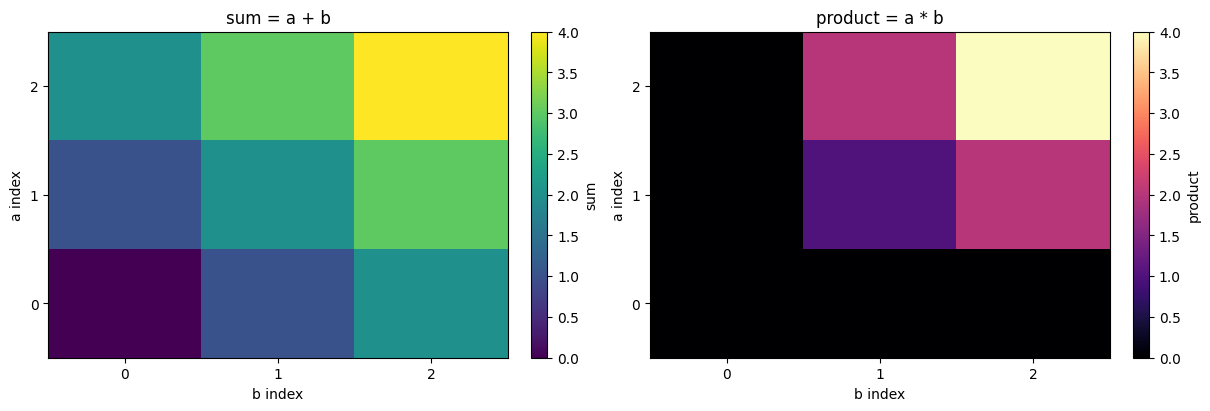

In [5]:
import matplotlib.pyplot as plt

from bayesian_metamodeling.tutorials import load_toy_heatmap_grids

a_vals, b_vals, sum_grid, prod_grid = load_toy_heatmap_grids(sweep_rows_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

im0 = axes[0].imshow(sum_grid, origin="lower", cmap="viridis", aspect="auto")
axes[0].set_title("sum = a + b")
axes[0].set_xlabel("b index")
axes[0].set_ylabel("a index")
axes[0].set_xticks(range(len(b_vals)), labels=[f"{v:g}" for v in b_vals])
axes[0].set_yticks(range(len(a_vals)), labels=[f"{v:g}" for v in a_vals])
fig.colorbar(im0, ax=axes[0], label="sum")

im1 = axes[1].imshow(prod_grid, origin="lower", cmap="magma", aspect="auto")
axes[1].set_title("product = a * b")
axes[1].set_xlabel("b index")
axes[1].set_ylabel("a index")
axes[1].set_xticks(range(len(b_vals)), labels=[f"{v:g}" for v in b_vals])
axes[1].set_yticks(range(len(a_vals)), labels=[f"{v:g}" for v in a_vals])
fig.colorbar(im1, ax=axes[1], label="product")

plt.show()


## Scientific checkpoint

- `sum` heatmap should increase linearly with both `a` and `b`.
- `product` heatmap should be low near zeros and increase fastest when both `a` and `b` are high.
- These patterns confirm the toy model equations and show how centralized sweep tables support immediate response-surface analysis.

**Hold this question for T5**: imagine you fitted a probabilistic surrogate on this 3×3 grid and asked it to predict `product` at `a = 0.5, b = 0.5` (a point you didn't run). Would you trust the prediction? Why or why not? You'll answer this directly in T5 when you train the PyMC GP surrogate on the same data and read its predictive width.


## Common mistakes
- Running the notebook from the wrong folder without `src/` in scope.
- Forgetting to run Step 2 before attempting sweep visualization.
- Assuming failed rows are included in heatmaps (this tutorial filters to `status == success`).


## Final check: T1 actually produced a sweep with successful rows

Asserts sweep_rows.csv exists for the toy run, has the expected number of points (3*3 = 9), and at least one row is `status == "success"`. If THIS cell raises, the rest of the curriculum's PyMC/SBI surrogate fits will have nothing to train on.

In [ ]:
# Self-check: T1 produced sweep_rows.csv with 3*3 = 9 success rows on the toy.
import csv as _csv
from pathlib import Path as _P
_sweeps = sorted((root / "tmp/tutorials/toy_store/sweeps").glob("*/sweep_rows.csv"),
                 key=lambda p: p.stat().st_mtime)
assert _sweeps, f"No T1 sweep_rows.csv under tmp/tutorials/toy_store/sweeps/. Steps 1-2 did not produce a sweep."
_latest = _sweeps[-1]
with open(_latest) as _f:
    _rows = list(_csv.DictReader(_f))
_success = [r for r in _rows if r.get("status") == "success"]
assert len(_rows) == 9, f"Expected 9 DOE points (3*3 grid) in {_latest.name}, got {len(_rows)}"
assert len(_success) == 9, f"Expected 9/9 successful runs, got {len(_success)}/9 in {_latest}"
print(f"\n[T1 self-check OK] {len(_success)}/{len(_rows)} success rows in {_latest.relative_to(root)}")
